# Tarea 1: Análisis Exploratorio de Datos (EDA)

**Objetivo:** Aplicar técnicas de exploración, limpieza y descripción estadística sobre un nuevo conjunto de datos.

**Instrucciones:**
1. Carga el dataset de los pasajeros del [Titanic](https://www.kaggle.com/competitions/titanic/data?select=train.csv).
2. Realiza una inspección inicial para entender la estructura de los datos.
3. Detecta y maneja datos faltantes y duplicados.
4. Extrae estadísticas descriptivas clave.
5. Escribe tus conclusiones sobre la calidad y contenido de los datos.

In [79]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual opcional
sns.set_style("whitegrid")

### 1. Carga de Datos
Carga el archivo CSV en un DataFrame de Pandas llamado `df`.
Muestra las primeras 5 filas y 5 filas aleatorias para verificar que se cargó correctamente.

In [80]:
df = pd.read_csv('train.csv')
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
864,865,0,2,"Gill, Mr. John William",male,24.0,0,0,233866,13.0000,NaN,S
339,340,0,1,"Blackwell, Mr. Stephen Weart",male,45.0,0,0,113784,35.5000,T,S
431,432,1,3,"Thorneycroft, Mrs. Percival (Florence Kate White)",female,NaN,1,0,376564,16.1000,NaN,S
622,623,1,3,"Nakid, Mr. Sahid",male,20.0,1,1,2653,15.7417,NaN,C
346,347,1,2,"Smith, Miss. Marion Elsie",female,40.0,0,0,31418,13.0000,NaN,S


In [81]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Inspección General
Responde a las siguientes preguntas mediante código:
* ¿Cuántas filas y columnas tiene el dataset? (`shape`)
* ¿Cuáles son los nombres de las columnas? (`columns`)
* ¿Qué tipos de datos (Dtype) tiene cada columna? (`info`)

In [82]:
# Tu código aquí
print(f"Tamaño del dataset: {df.shape}")
print(f"Tenemos {df.shape[0]} filas y {df.shape[1]} columnas.")
print("Nombre de las columnas: ")
print(list(df.columns))

Tamaño del dataset: (891, 12)
Tenemos 891 filas y 12 columnas.
Nombre de las columnas: 
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 3. Calidad de los Datos
Antes de analizar estadísticas, debemos limpiar:
1.  **Duplicados:** Verifica si hay filas duplicadas y elimínalas si existen.
2.  **Valores Nulos:** Muestra cuántos valores nulos (NaN) hay por columna.
    * *Reto:* Si encuentras nulos en variables numéricas, rellénalos con la **Mediana** (como vimos en clase para evitar sesgos por outliers).

In [84]:
# 1. Verificar y borrar duplicados
if df.duplicated().any():
    df = df.drop_duplicates()
    print("Duplicados eliminados")
    print(f"Tamaño del dataset post eliminacion de duplicados: {df.shape}")
else:
    print("No había duplicados")

# 2. Conteo de nulos
print(df.isnull().sum())

print("\nRellenar Age con la mediana por ser varible numerica")

# 3. Imputación (fillna)
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

No había duplicados
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Rellenar Age con la mediana por ser varible numerica


### 4. Estadística Descriptiva
Utiliza la función `describe()` para obtener un resumen de las variables numéricas (media, desviación estándar, mínimos y máximos).

**Pregunta de análisis:** ¿Notas alguna columna con una desviación estándar (`std`) muy alta o valores máximos (`max`) extraños?

In [85]:
# Tu código aquí (.describe().T es recomendable para leerlo mejor)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


#RESPUESTA DE ANÁLISIS:
En la columna Fare, precio del billete, la desviación estándar (49.69) es más grande que la media (32.2),
además observamos que en la columna mínimo tenemos 0.0 por lo que algunos pasajeros viajaron gratis. Pero, en la
columna max tenemos el billete más caro 512,3292. Por tanto, podemos afirmar que hay outliers en la columna que
hacen que la desviación estándar sea muy alta.


### 5. Análisis de Variables Categóricas (Object)
Selecciona una columna de tipo texto (categórica) y cuenta cuántas veces aparece cada valor único (frecuencia).
*Pista: Usa `value_counts()`*

In [86]:
conteo = df['Survived'].value_counts()
print(conteo)

Survived
0    549
1    342
Name: count, dtype: int64


### 6. Conclusiones del Análisis
Escribe aquí un breve párrafo resumiendo qué descubriste sobre el dataset:
* ¿Estaban los datos muy sucios?
* ¿Cuál es la variable con mayor dispersión?
* ¿Qué patrones iniciales observas?

- Los datos no estaban muy sucios en cuanto a las variables numéricas. La única que presentaba nulos era la Edad y aún así, más del 70% de las filas tenían valor numérico ya puesto. Otra columna que estaba muy sucia era la de la Cabina pero como no afectaba al ejercicio se podía quedar con nulos. Si hubiéramos querido hacer una correlación entre calidad de pasaje y supervivencia, en vez de usar la cabina que estaba sucia podríamos usar PClass que de cierto modo nos indica también la cabina, al estar codificada como Anum, Bnum, Cnum, haicendo referencia supongo a 1ª clase, 2ª clase y 3ª clase.

- La variable con mayor dispersión es Fare, precio del billete. Lo cual tiene sentido por la gran diferencia entre el valor minimo 0 y el valor maximo 512. Al haber picos tan distintos, se nos genera una desviación alta por culpa de Outliers.

- Para ver patrones iniciales, primero tendré que hacer supuestas relaciones, véase a continuación

In [87]:
print("\nSupervivencia por sexo:")
print(df.groupby('Sex')['Survived'].value_counts())

print("\nSupervivencia por clase:")
print(df.groupby('Pclass')['Survived'].value_counts())


Supervivencia por sexo:
Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

Supervivencia por clase:
Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64


Como patrones iniciales he querido comprobar la relación entre el sexo del pasajero y la tasa de supervivencia. Observamos:
1. Las mujeres tienen mayor índice de supervivencia que los hombres, de hecho, el número de muertes de mujeres se acerca al de superviviencia del hombre.
2. Si eras hombre en el Titanic, tus probabilidades de muerte eran mucho más altas que las de las mujeres.

Otra relación que quise estudiar fue la tasa de supervivencia dependiendo de la clase del pasajero, se observa:
1. Si eres de primera Clase tienes más probabilidades de sobrevivir al hundimiento
2. Si eres de segunda clase, tus probabilidades se acercan al 50%
3. Si eres de tercera clase, es más probable que terminases ahogado con el hundimiento.

#Parte 2. Ejercicios extras. (COMPLETAMENTE OPCIONAL, SOLO SE EVALUA LO ANTERIOR)

## Extra 1: Filtrado de Datos

Crea un nuevo DataFrame llamado `df_sobrevivientes` que contenga solo a los pasajeros que sobrevivieron (`Survived == 1`) y muestra cuántos son.

In [88]:
df_sobrevivientes = df[df['Survived'] == 1].copy()
df_sobrevivientes.shape[0]

342

## Extra 2: Agrupación

Calcula el precio promedio del ticket (`Fare`) por cada clase (`Pclass`). ¿Es la primera clase significativamente más cara?

In [89]:
df.groupby('Pclass')['Fare'].mean()


,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


In [90]:
print("Si, la primera clase es mucho más cara que las otras")

Si, la primera clase es mucho más cara que las otras


# Extra 3: Visualización Básica

Crea un histograma simple para ver la distribución de las edades de todos los pasajeros.

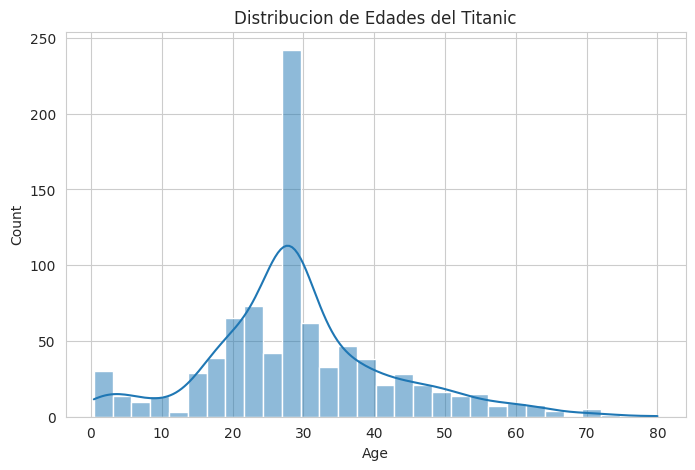

In [91]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Distribucion de Edades del Titanic")
plt.show()

# Extra 4: Creamos nuestra tabla cruzada

Utiliza `pd.crosstab` para ver la relación entre la Clase (`Pclass`) y si sobrevivió o no (`Survived`).

In [92]:
tabla_cruzada = pd.crosstab(df['Pclass'], df['Survived'])
tabla_cruzada

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


# Extra 5: Ingeniería de variables

Crea una nueva columna llamada `FamilySize` que sea la suma de `SibSp` (hermanos/esposos) y `Parch` (padres/hijos) + 1 (el pasajero mismo).

In [93]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


# Extra 6: Ordenamiento

Muestra los 5 pasajeros que pagaron la tarifa más alta (Fare), ordenando el DataFrame de forma descendente.

In [94]:
top_val = df.sort_values(by = 'Fare', ascending=False).head(5)
top_val[['PassengerId', 'Survived', 'Name', 'Fare', 'Age']]

,PassengerId,Survived,Name,Fare,Age
679,680,1,"Cardeza, Mr. Thomas Drake Martinez",512.3292,36.0
258,259,1,"Ward, Miss. Anna",512.3292,35.0
737,738,1,"Lesurer, Mr. Gustave J",512.3292,35.0
88,89,1,"Fortune, Miss. Mabel Helen",263.0000,23.0
438,439,0,"Fortune, Mr. Mark",263.0000,64.0
